# 06 – Análise de Sobrevivência
**Objetivo:** Aplicar técnicas de análise de sobrevivência para estimar as funções de probabilidade de sobrevivência ao longo do tempo de internação e modelar o risco (hazard) utilizando a Regressão de Cox.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Lifelines (Survival Analysis library)
# pip install lifelines
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
FIG_PATH = Path('../reports/figures')
FIG_PATH.mkdir(parents=True, exist_ok=True)


## 1. Preparação dos Dados
A análise de sobrevivência requer a variável de **tempo** (`dias_permanencia` ou `tempo_sobrevida`). Como essas variáveis foram removidas da base reduzida (para evitar vazamento no ML), usaremos a **base_modelagem.csv** original e faremos uma seleção de features manuais de interesse clínico.

In [4]:
DATA_PATH = Path('../data/processed/base_modelagem.csv')
df = pd.read_csv(DATA_PATH, low_memory=False)

# Garantir formato correto
df['indicador_obito'] = pd.to_numeric(df['indicador_obito'], errors='coerce')
df['dias_permanencia'] = pd.to_numeric(df['dias_permanencia'], errors='coerce')

# Variáveis básicas para sobrevida
T = df['dias_permanencia']  # Tempo
E = df['indicador_obito']   # Evento (1 = Óbito, 0 = Censura/Alta)

print(f"Base carregada. Casos totais: {len(df)}")
print(f"Óbitos confirmados: {E.sum()}")

Base carregada. Casos totais: 380591
Óbitos confirmados: 35911


## 2. Estimador de Kaplan-Meier (Curva Global)
Plotar a curva de sobrevivência global da amostra ao longo dos dias de internação.

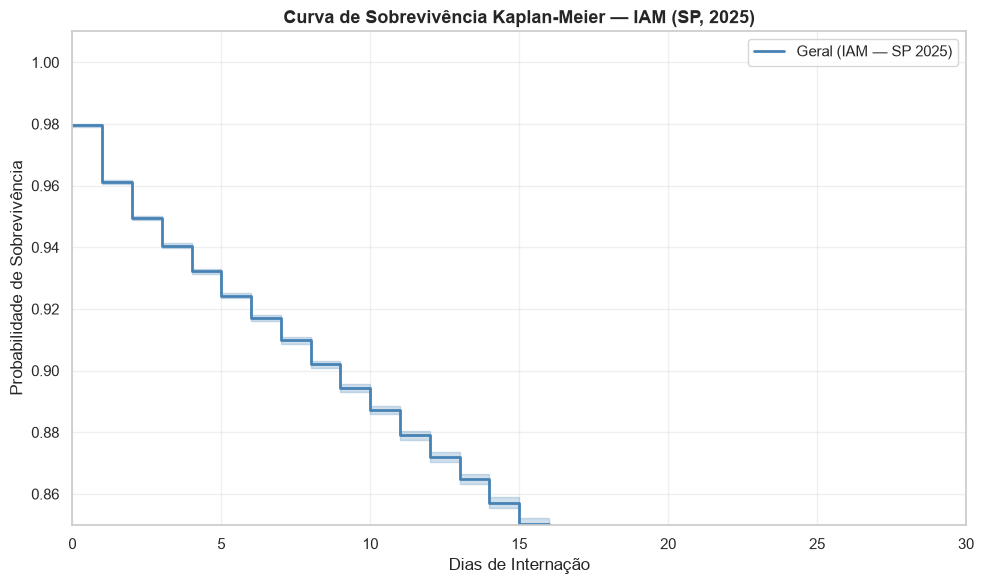

Figura salva em reports/figures/km_global.png
Mediana de sobrevivência: 79.0 dias


In [5]:
kmf = KaplanMeierFitter()
kmf.fit(durations=T, event_observed=E, label='Geral (IAM — SP 2025)')

fig, ax = plt.subplots(figsize=(10, 6))
kmf.plot_survival_function(ax=ax, color='steelblue', linewidth=2)
ax.set_title('Curva de Sobrevivência Kaplan-Meier — IAM (SP, 2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Probabilidade de Sobrevivência')
ax.set_xlabel('Dias de Internação')
ax.set_xlim(0, 30)
ax.set_ylim(0.85, 1.01)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_PATH / 'km_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva em reports/figures/km_global.png")
print(f"Mediana de sobrevivência: {kmf.median_survival_time_} dias")


## 3. Sobrevivência Estratificada
Comparar curvas de sobrevivência entre grupos (ex: Sexo, Caráter de Atendimento) usando o Log-Rank Test.

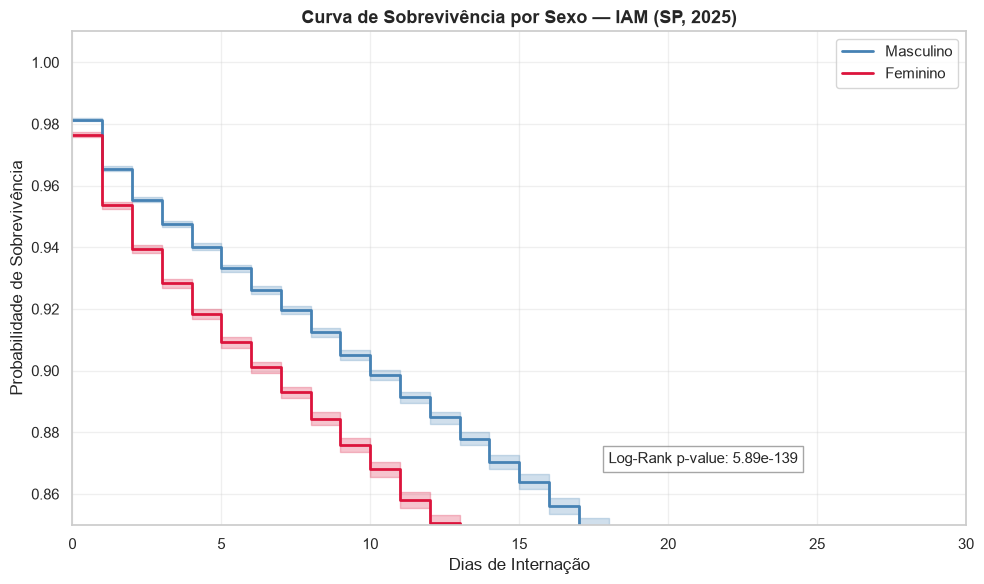

Figura salva em reports/figures/km_por_sexo.png
Log-Rank p-value: 5.8933e-139
Conclusão: Diferença estatisticamente significativa (p < 0.05)


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

mask_m = df['sexo'] == 1
mask_f = df['sexo'] == 3

kmf_m = KaplanMeierFitter()
kmf_f = KaplanMeierFitter()

kmf_m.fit(T[mask_m], event_observed=E[mask_m], label='Masculino')
kmf_m.plot_survival_function(ax=ax, color='steelblue', linewidth=2)

kmf_f.fit(T[mask_f], event_observed=E[mask_f], label='Feminino')
kmf_f.plot_survival_function(ax=ax, color='crimson', linewidth=2)

ax.set_title('Curva de Sobrevivência por Sexo — IAM (SP, 2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Probabilidade de Sobrevivência')
ax.set_xlabel('Dias de Internação')
ax.set_xlim(0, 30)
ax.set_ylim(0.85, 1.01)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Log-Rank Test
results = logrank_test(T[mask_m], T[mask_f], event_observed_A=E[mask_m], event_observed_B=E[mask_f])
ax.text(18, 0.87, f"Log-Rank p-value: {results.p_value:.2e}", fontsize=11,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

plt.tight_layout()
plt.savefig(FIG_PATH / 'km_por_sexo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva em reports/figures/km_por_sexo.png")
print(f"Log-Rank p-value: {results.p_value:.4e}")
print(f"Conclusão: {'Diferença estatisticamente significativa (p < 0.05)' if results.p_value < 0.05 else 'Sem diferença significativa'}")


## 4. Modelo de Riscos Proporcionais de Cox (CoxPH)
O modelo de Cox permite avaliar o efeito de múltiplas variáveis independentes sobre o risco de ocorrência do óbito (Hazard Ratio).

=== Modelo de Riscos Proporcionais de Cox ===


<lifelines.CoxPHFitter: fitted with 380591 total observations, 344680 right-censored observations>
             duration col = 'dias_permanencia'
                event col = 'indicador_obito'
      baseline estimation = breslow
   number of observations = 380591
number of events observed = 35911
   partial log-likelihood = -427965.49
         time fit was run = 2026-08-20 19:15:39 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
idade               0.04      1.04      0.00            0.04            0.04                1.04                1.05
sexo                0.12      1.13      0.01            0.10            0.14                1.10                1.15
carater_internacao  0.50      1.65      0.03            0.45            0.55                1.57                1.74
usou_uti            0.00      1.00      0.01           -0.02            0.02                0.98                1.02

                    cmp to     z      p  -log2(p)
covariate                                        
idade                 0.00 94.66 <0.005       inf
sexo                  0.00 11.04 <0.005     91.74
carater_internacao    0.00 19.11 <0.005    268.06
usou_uti              0.00  0.31   0.76      0.40
---
Concordance = 0.65
Partial AIC = 855938.99
log-likelihood ratio test = 10445.01 on 4 df
-log2(p) of ll-ratio test = inf

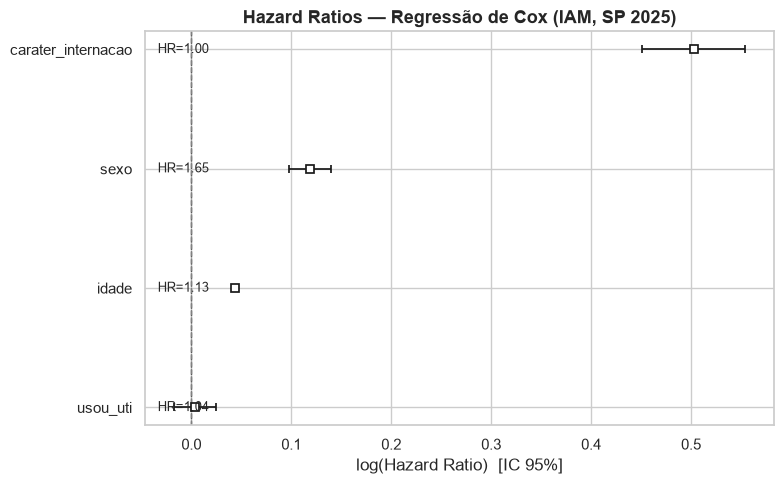

Figura salva em reports/figures/cox_hazard_ratios.png

INTERPRETAÇÃO DO HAZARD RATIO (exp(coef)):
- Valores > 1 indicam que a variável AUMENTA o risco de óbito.
- Valores < 1 indicam que a variável REDUZ o risco de óbito (proteção).

Concordance Index (C-statistic): 0.6464


In [7]:
cols_cox = ['dias_permanencia', 'indicador_obito', 'idade', 'sexo', 'carater_internacao', 'uti_mes_total']
df_cox = df[cols_cox].copy().dropna()
df_cox['sexo']               = df_cox['sexo'].map({1: 0, 3: 1})
df_cox['carater_internacao'] = df_cox['carater_internacao'].map({1: 0, 2: 1})
df_cox['usou_uti']           = (df_cox['uti_mes_total'] > 0).astype(int)
df_cox.drop(columns=['uti_mes_total'], inplace=True)

cph = CoxPHFitter()
cph.fit(df_cox, duration_col='dias_permanencia', event_col='indicador_obito')

print("=== Modelo de Riscos Proporcionais de Cox ===")
cph.print_summary()

# Plotar Hazard Ratios
fig, ax = plt.subplots(figsize=(8, 5))
cph.plot(ax=ax)
ax.set_title('Hazard Ratios — Regressão de Cox (IAM, SP 2025)', fontsize=13, fontweight='bold')
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('log(Hazard Ratio)  [IC 95%]')

# Adicionar rótulos com valores do HR
for i, (covar, row) in enumerate(cph.params_.items()):
    hr = cph.hazard_ratios_[covar]
    ax.text(0.02, i, f"HR={hr:.2f}", va='center', fontsize=9, transform=ax.get_yaxis_transform())

plt.tight_layout()
plt.savefig(FIG_PATH / 'cox_hazard_ratios.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva em reports/figures/cox_hazard_ratios.png")

print("\nINTERPRETAÇÃO DO HAZARD RATIO (exp(coef)):")
print("- Valores > 1 indicam que a variável AUMENTA o risco de óbito.")
print("- Valores < 1 indicam que a variável REDUZ o risco de óbito (proteção).")
print(f"\nConcordance Index (C-statistic): {cph.concordance_index_:.4f}")
